#### Train Set과 Test Set의 필요성
- 모든 문제와 답을 알려주고 해당 범위내에서 점수를 내면 항성 100점이 나온다.
- 한개의 Data Set을 Train 부분과 Test 부분으로 분리
- Train Set은 학습하고 학습한 결과 내용으로 Test Set 으로 검증하여야 모델의 정확한 정확성을 신뢰할 수 있다.

In [5]:
import pandas as pd

In [6]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


#### Train Set 과 Test Set로 분리하기

In [7]:
# Train Set
train_input = fruits.loc[:34,['length', 'weight']]
train_input.tail()

,length,weight
30,38.5,920.0
31,38.5,955.0
32,39.5,925.0
33,41.0,975.0
34,41.0,950.0


In [8]:
train_target = fruits.loc[:34,'name']
train_target.tail()

30    apple
31    apple
32    apple
33    apple
34    apple
Name: name, dtype: object

In [9]:
# Test Set
test_input = fruits.loc[34:,['length', 'weight']]
test_input.tail()

,length,weight
44,12.2,12.2
45,12.4,13.4
46,13.0,12.2
47,14.3,19.7
48,15.0,19.9


In [10]:
# Test Target
test_target = fruits.loc[34:,'name']
test_target.tail()

44    berry
45    berry
46    berry
47    berry
48    berry
Name: name, dtype: object

#### KNN을 이용한 분류

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
# Model
kn = KNeighborsClassifier()

In [13]:
# 학습시키기
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
# 평가하기
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
0.06666666666666667


> 샘플링 편향이 발생하였다.

#### Numpy를 이용하여 샘플링 편향 제거하기

In [15]:
import numpy as np

In [16]:
np.random.seed(42) # random sample을 하나로 정의하여 다른 모델에서도 동일한 값으로 진행
index = np.arange(49)
np.random.shuffle(index)
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [17]:
# train data 구성
train_input = fruits.loc[index[:35], ['length', 'weight']]
train_input.head()

,length,weight
13,32.0,340.0
45,12.4,13.4
47,14.3,19.7
44,12.2,12.2
17,33.0,700.0


In [18]:
train_target = fruits.loc[index[:35],'name']
train_target.head()

13    apple
45    berry
47    berry
44    berry
17    apple
Name: name, dtype: object

In [19]:
# test data 구성
test_input = fruits.loc[index[35:], ['length', 'weight']]
test_input.head()

,length,weight
37,10.6,7.0
35,9.8,6.7
23,35.0,680.0
39,11.2,9.8
10,31.0,475.0


In [20]:
# test target 구성
test_target = fruits.loc[index[35:],'name']
test_target.head()

37    berry
35    berry
23    apple
39    berry
10    apple
Name: name, dtype: object

#### Data의 분포를 산포도로 확인하기

In [21]:
import matplotlib.pyplot as plt

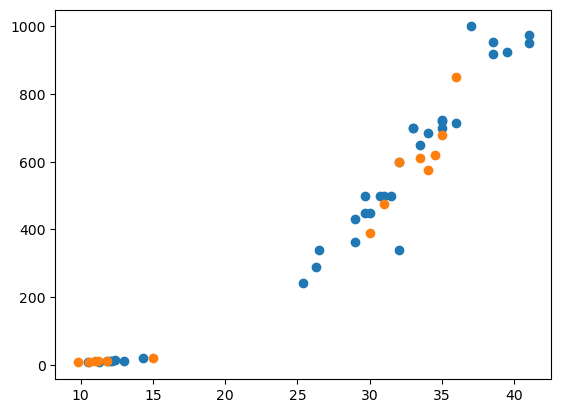

In [22]:
plt.scatter(
    train_input['length'],
    train_input['weight']
)
plt.scatter(
    test_input['length'],
    test_input['weight']
)

plt.show()

In [23]:
# knn으로 학습
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
# knn 으로 정확도 출력(train, test)
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0


---
#### sklearn 으로 Train Set 과 Test set 나누기

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# Feature와 Target으로 분리
fruits_data = fruits[['length', 'weight']]
fruits_data.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [27]:
fruits_targert = fruits['name']
fruits_targert.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [28]:
train_input, test_input, train_target, test_target =\
    train_test_split(
        fruits_data,
        fruits_targert,
        random_state = 42,
        stratify=fruits_targert # target의 비율을 검토
    )

In [29]:
# 크기 확인
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(36, 2) (36,)
(13, 2) (13,)


#### 빈도수 확인

In [30]:
import collections

In [31]:
# fruits의 성격
collections.Counter(train_target)

Counter({'apple': 26, 'berry': 10})

In [32]:
25/11

2.272727272727273

In [33]:
# test의 빈도수
collections.Counter(test_target)

Counter({'apple': 9, 'berry': 4})

> apple과 berry의 비율이 비슷하게 할 필요가 있다 <- Sampling의 기본